# Unsupervised Learning  
## Clustering Algorithms  


## Assignment Instructions

In this assignment, you will perform a clustering analysis on country locations using latitude and longitude data.  
You will follow these steps:

1. **Import the relevant libraries.**  
2. **Load the dataset (`countries.csv`).**  
3. **Visualize the data by plotting longitude vs. latitude.**  
4. **Select the features for clustering.**  
5. **Perform clustering analysis and Evaluate clustering results.**  
6. **Explore clustering solutions and select the number of clusters** 

Ensure that you document your analysis and interpretations in Markdown cells.  


1. Import the relevant libraries.

In [22]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


2. Load the dataset (countries.csv).

In [23]:
# Load the dataset
file_path = 'countries.csv'
data = pd.read_csv(file_path)

# Display the first few rows
data.head()

,country,latitude,longitude,name
0,AD,42.546245,1.601554,Andorra
1,AE,23.424076,53.847818,United Arab Emirates
2,AF,33.939110,67.709953,Afghanistan
3,AG,17.060816,-61.796428,Antigua and Barbuda
4,AI,18.220554,-63.068615,Anguilla


4. Visualize the data by plotting longitude vs. latitude.

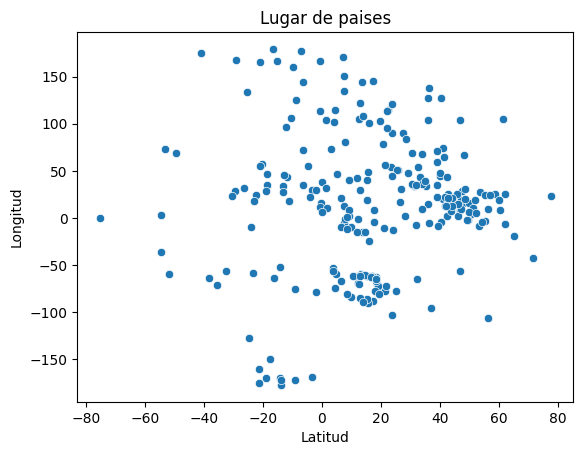

In [24]:
# Plotting Satisfaction Score vs Loyalty Level
import seaborn as sns
sns.scatterplot(x=data['latitude'], y=data['longitude'])
plt.title("Lugar de paises")
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.show()

4. Select the features for clustering.

In [25]:
# Selecting features for clustering
features = data[['latitude', 'longitude']]
features.head()

,latitude,longitude
0,42.546245,1.601554
1,23.424076,53.847818
2,33.939110,67.709953
3,17.060816,-61.796428
4,18.220554,-63.068615


Standardize the features for clustering and Drop rows with missing values

In [26]:
# Standardize the features for clustering
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Drop rows with missing values
features_scaled = features_scaled[~np.isnan(features_scaled).any(axis=1)]


5.Perform clustering analysis using the Elbow method to find the optimal number of clusters

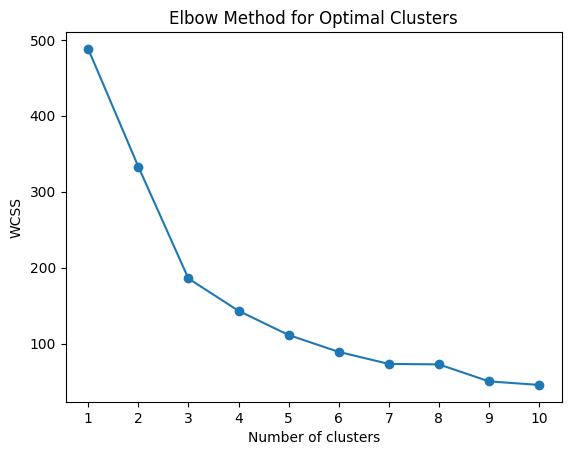

In [27]:
# Using the Elbow method to find the optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(features_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow method results
plt.plot(range(1, 11, 1), wcss, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11, 1), fontsize=10)
plt.yticks(fontsize=10)
plt.show()

6.Explore clustering solutions and select the number of clusters

Centros de los clusters (datos escalados):
[[ 0.94338212  0.19522058]
 [-0.80284772  0.85896837]
 [-0.45889884 -1.1485455 ]]

Centros de los clusters (escala original):
[[ 41.70155657  27.70692005]
 [ -5.40431588  76.7079213 ]
 [  3.8739655  -71.49624758]]


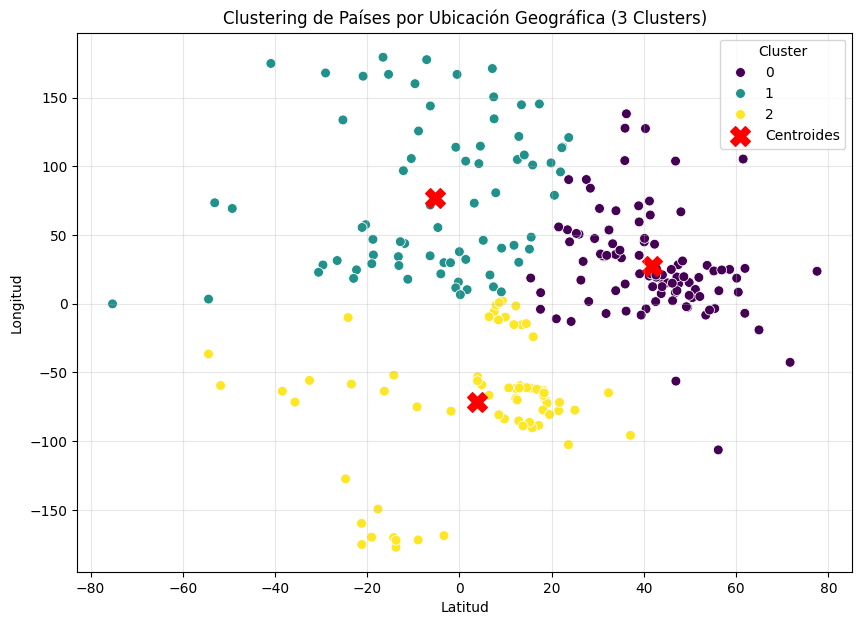

In [28]:
# Drop rows with missing values in the original DataFrame
data_cleaned = data.dropna(subset=['latitude', 'longitude']).copy()

# Selecting the optimal number of clusters based on the Elbow method
optimal_clusters = 3

# Adjust based on the elbow plot
selected_features = data_cleaned[['latitude', 'longitude']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(selected_features)

# Performing clustering
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_scaled)

# Visualizing the clustering results
data_cleaned['cluster'] = cluster_labels
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

print('Centros de los clusters (datos escalados):')
print(centers_scaled)
print()
print('Centros de los clusters (escala original):')
print(centers_original)

# Definir el número óptimo de clusters (en este caso 3)
optimal_clusters = 3

# Crear y ajustar el modelo K-Means
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
data_cleaned['cluster'] = kmeans.fit_predict(features_scaled)

# Añadir las etiquetas de cluster al dataframe original
data['cluster'] = np.nan
data.loc[data_cleaned.index, 'cluster'] = data_cleaned['cluster']

# Visualizar los clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=data_cleaned,
    x='latitude',
    y='longitude',
    hue='cluster',
    palette='viridis',
    s=50
)
plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    s=200,
    c='red',
    marker='X',
    label='Centroides'
)
plt.title('Clustering de Países por Ubicación Geográfica (3 Clusters)')
plt.xlabel('Latitud')
plt.ylabel('Longitud')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

